# Scene Classification 
**Author: Eng. Noureldin Bassem Mohamed**

## 1. Introduction

A stock photography platform lets photographers upload landscape and travel photos, and lets buyers
search that library by scene type, things like forest, mountain, or street. Right now every upload gets
tagged by hand, and the backlog of untagged photos keeps growing faster than the review team can clear
it. I will build a model that looks at an uploaded photo and sorts it into the right scene category automatically,
so photographers get their work live faster and the review team can spend their time on the photos the
model is genuinely unsure about.

## 2. Import Libraries

In [4]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
import keras

from sklearn.metrics import(
classification_report,
f1_score,
accuracy_score,
confusion_matrix,
balanced_accuracy_score
)

## 3. Loading Data

In [5]:
data_dir="/kaggle/input/datasets/puneet6060/intel-image-classification"

train_dir=os.path.join(data_dir,"seg_train/seg_train")

test_dir=os.path.join(data_dir,"seg_test/seg_test")

pred_dir=os.path.join(data_dir,"seg_pred/seg_pred")

artifacts="artifacts"

## 4. Variables Intialization

In [6]:
img_size=(224,224)
batch_size= 32
val_split=0.2
seed=42

epochs_head=15
epochs_fine_tune=8
lr_head=1e-3
lr_fine_tune=1e-5

os.makedirs(artifacts, exist_ok=True)
keras.utils.set_random_seed(seed)

## 5. EDA

### 5.1 Building Index For Every File

In [7]:
def index_images(base_path,name):
    rows=[]
    for class_ in sorted(os.listdir(base_path)):
        class_dir=os.path.join(base_path,class_)

        if not os.path.isdir(class_dir):
            continue
        for image_name in sorted(os.listdir(class_dir)):
            rows.append({
                "image_path": os.path.join(class_dir,image_name),
                "class_name": class_,
                "split_name": name
            })
    return pd.DataFrame(rows)

all_images_df=pd.concat([index_images(train_dir,"train"),index_images(test_dir,"test")],ignore_index=True )

all_images_df.head()
        
        
    
    

,image_path,class_name,split_name
0,/kaggle/input/datasets/puneet6060/intel-image-...,buildings,train
1,/kaggle/input/datasets/puneet6060/intel-image-...,buildings,train
2,/kaggle/input/datasets/puneet6060/intel-image-...,buildings,train
3,/kaggle/input/datasets/puneet6060/intel-image-...,buildings,train
4,/kaggle/input/datasets/puneet6060/intel-image-...,buildings,train


### 5.2 Defining Classes

In [8]:
class_names=sorted(all_images_df["class_name"].unique())

print(f"class names: {class_names}")

class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### 5.3 Checking Class Balance

In [9]:
class_balance_check=all_images_df.groupby(['split_name','class_name']).count().unstack(fill_value=0).loc[['train','test']]
display(class_balance_check)

image_path                                     
class_name  buildings forest glacier mountain   sea street
split_name                                                
train            2191   2271    2404     2512  2274   2382
test              437    474     553      525   510    501

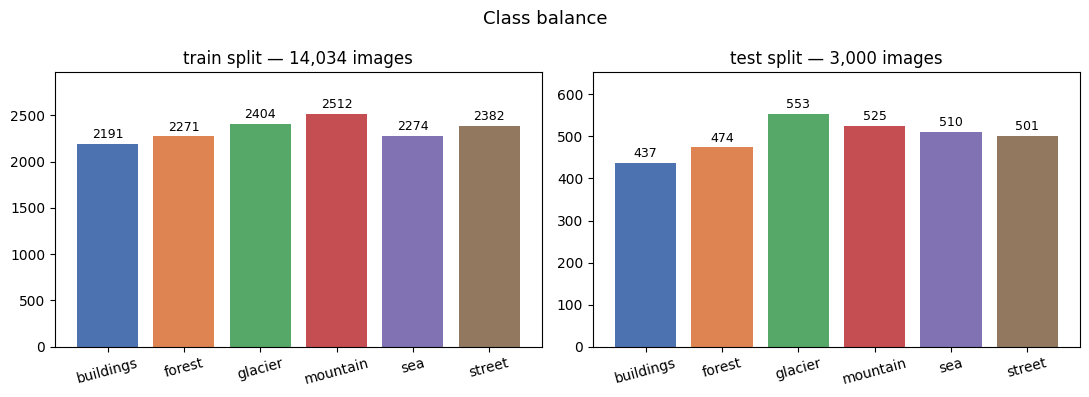

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split in zip(axes, ["train", "test"]):
    subset = class_balance_check.loc[split]
    
    x_labels = [col[1] if isinstance(col, tuple) else str(col) for col in subset.index]
    
    bars = ax.bar(x_labels, subset.values, color=sns.color_palette("deep", len(x_labels)))
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(f"{split} split — {subset.sum():,} images")
    ax.set_ylim(0, subset.max() * 1.18)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Class balance", fontsize=13)
fig.tight_layout()
plt.show()

The classes are balanced

### 5.4 Looking At Images

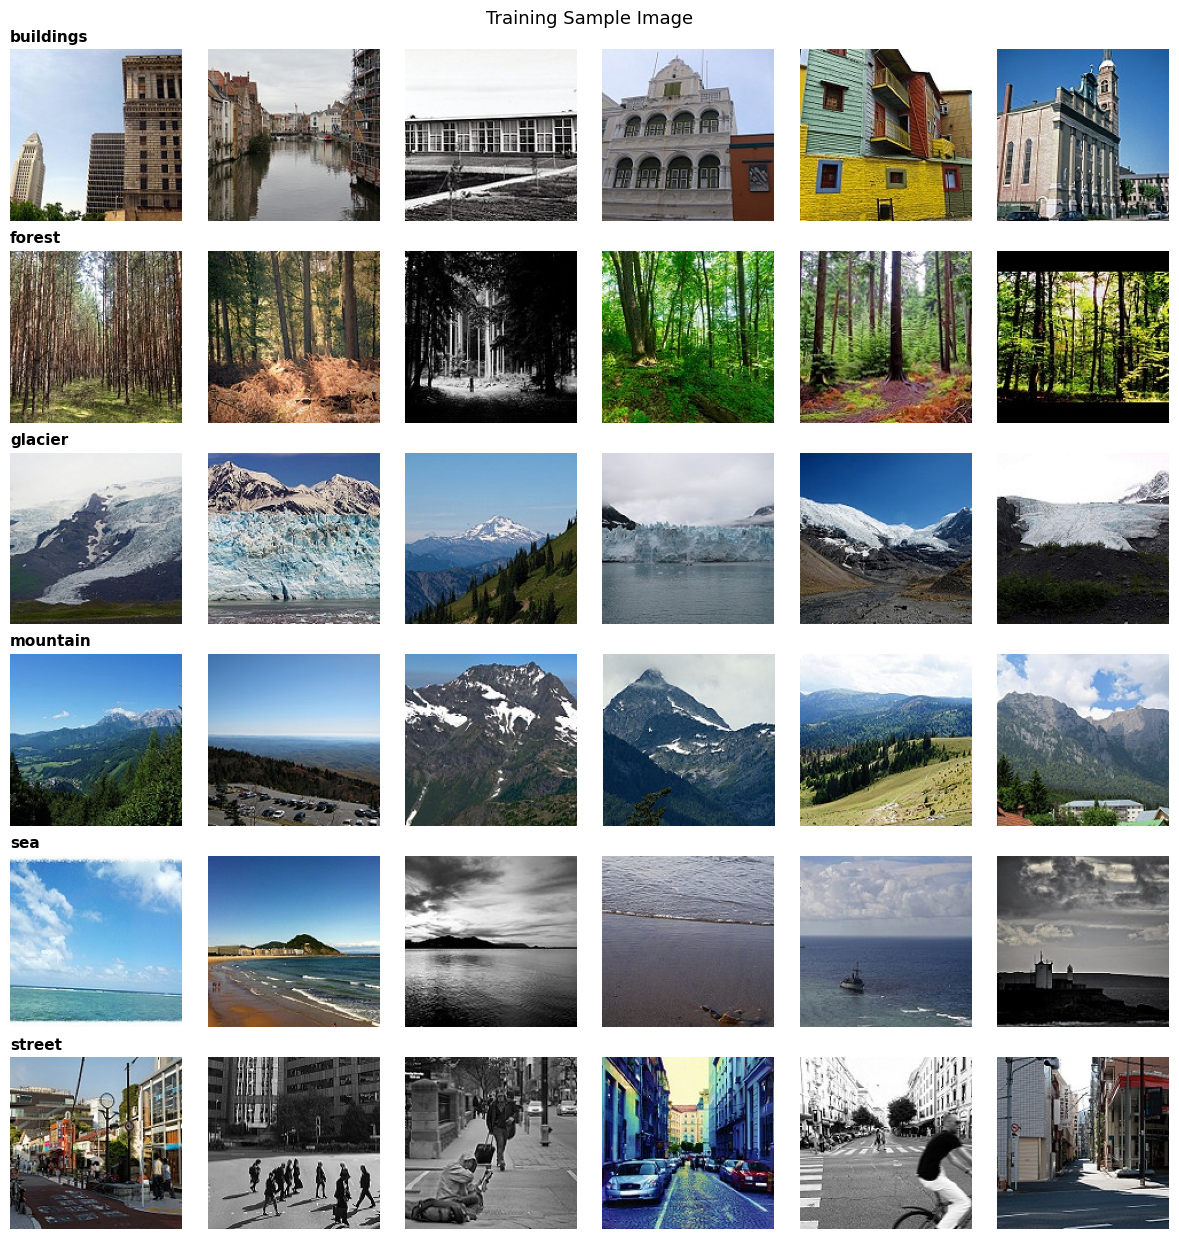

In [11]:
def show_images (df,n_per_class=6,seed=seed):
    fig,axes=plt.subplots(len(class_names),n_per_class,figsize=(n_per_class*2,2.1*len(class_names)))
    for i, label in enumerate(class_names):
        subset=df[df["class_name"]==label].sample(n=n_per_class,random_state=seed)
        for col,(_,row_data) in enumerate(subset.iterrows()):
            ax=axes[i,col]
            img=Image.open(row_data["image_path"])
            ax.imshow(img)
            ax.axis("off")
            if col==0:
                ax.set_title(label,fontsize=11,fontweight="bold",loc="left")
    fig.suptitle("Training Sample Image",fontsize=13)
    fig.tight_layout()
    plt.show()


show_images(all_images_df[all_images_df["split_name"]=="train"])

- I observed that some images are colored while the other are grayscaled
- some mountain and glacier images may confuse the model
- also a few sea and mountain images may confuse the model


## 6. Building The Model

Before writing any code I had to pick a few things, so here is what I chose and why:

- **TensorFlow / Keras** because I am faster with it, and the whole pipeline (reading the class folders, augmentation, saving one `.keras` file for the Streamlit app) is short to write.
- **Transfer learning instead of a CNN from scratch.** 14k images is not much for a network that has to learn edges and textures from zero, and the six classes are ordinary natural scenes, exactly the kind of thing an ImageNet backbone already knows. A from scratch CNN would need much longer training to reach the same place.
- **MobileNetV2 as the backbone** because it is small (about 2.2M parameters), so training is quick and, more importantly, the saved model stays light enough to run on a free Streamlit server.
- **224x224 input** even though the images are 150x150, because that is the size MobileNetV2 was trained on and its ImageNet features transfer better at that size.
- **20% of the training folder as validation**, and I do not touch the `seg_test` folder until the very end. Every decision I make (early stopping, learning rate, how much to unfreeze) is made on the validation split, so the test numbers stay honest.
- **Light augmentation only**: horizontal flip, small rotation, small zoom. A mountain is still a mountain when mirrored, but I avoided vertical flips and heavy color changes because sky on top is a real signal for these classes and I did not want to destroy it.

In [12]:
common=dict(
    image_size=img_size,
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="int"
)


train_ds=tf.keras.utils.image_dataset_from_directory(
train_dir,validation_split=val_split, subset="training", seed=seed, **common
)


val_ds=tf.keras.utils.image_dataset_from_directory(
train_dir,validation_split=val_split, subset="validation", seed=seed, **common
)


test_ds=tf.keras.utils.image_dataset_from_directory(
test_dir,seed=seed,shuffle=False, **common
)




Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1787500690.207240      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787500690.210228      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [13]:
data_augmentation=keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.05),
        keras.layers.RandomZoom(0.10)
    ],
    name="data_augmentation"
)

### 6.1 Model A

In [14]:
def build_model(num_classes=6):
    backbone=keras.applications.MobileNetV2(
        input_shape=img_size+ (3,),
        include_top=False,
        weights="imagenet"
    )

    backbone.trainable=False

    inputs= keras.Input(shape=img_size + (3,), name="Scene_Image")

    x=data_augmentation(inputs)
    x=keras.applications.mobilenet_v2.preprocess_input(x)
    x=backbone(x,training=False)
    x=keras.layers.GlobalAveragePooling2D(name="pooling")(x)
    x=keras.layers.Dropout(0.3, name="dropout")(x)
    outputs=keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name="Scene_Classifier"),backbone


model,backbone= build_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_head),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Scene_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Scene_Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling                         │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
callbacks_head=[
    keras.callbacks.EarlyStopping(
        monitor="val_loss",patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",factor=0.3, patience=2, min_lr=1e-6, verbose=1
    )
]

start=time.time()

history_head=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_head,
    callbacks=callbacks_head,
    verbose=2
)

time_head= time.time()- start


print(f"\nStage A finished in {time_head/60:.1f} minutes over {len(history_head.epoch)} epochs")



Epoch 1/15
351/351 - 33s - 93ms/step - accuracy: 0.8294 - loss: 0.4661 - val_accuracy: 0.9123 - val_loss: 0.2775 - learning_rate: 0.0010
Epoch 2/15
351/351 - 22s - 62ms/step - accuracy: 0.8870 - loss: 0.3057 - val_accuracy: 0.9063 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 3/15
351/351 - 22s - 62ms/step - accuracy: 0.8952 - loss: 0.2892 - val_accuracy: 0.9166 - val_loss: 0.2400 - learning_rate: 0.0010
Epoch 4/15
351/351 - 22s - 63ms/step - accuracy: 0.8958 - loss: 0.2870 - val_accuracy: 0.9191 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 5/15
351/351 - 23s - 64ms/step - accuracy: 0.8974 - loss: 0.2739 - val_accuracy: 0.9177 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 6/15
351/351 - 23s - 65ms/step - accuracy: 0.9015 - loss: 0.2655 - val_accuracy: 0.9155 - val_loss: 0.2363 - learning_rate: 0.0010
Epoch 7/15

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
351/351 - 23s - 65ms/step - accuracy: 0.9032 - loss: 0.2626 - val_accuracy: 0.9166 - val_l

In [16]:
model.save(os.path.join(artifacts, "model_a_feature_extraction.keras"))
print("saved model A")

saved model A


I saved model A

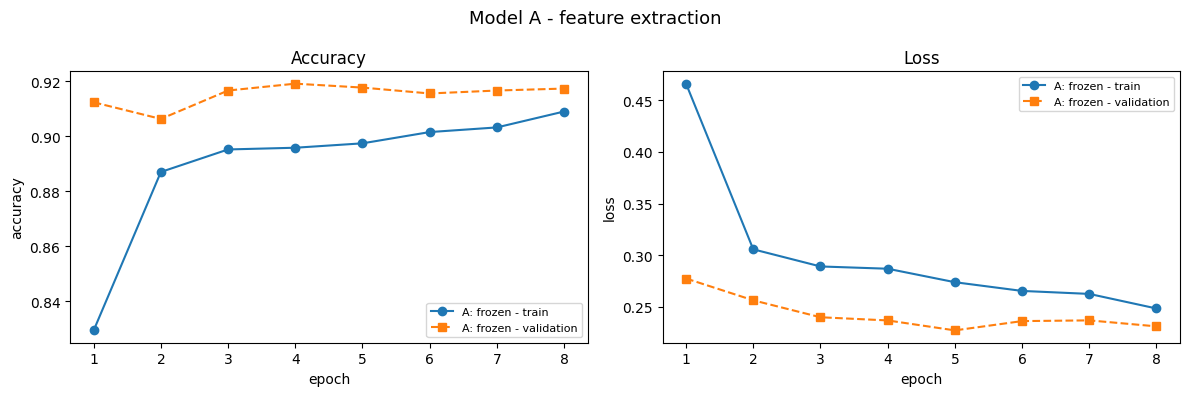

Best epoch 5: val_accuracy = 0.9177, val_loss = 0.2273


In [17]:
def plot_history(histories, title):
    """Plot accuracy and loss curves. `histories` is a list of (label, keras History)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epoch_offset = 0
    for i, (label, h) in enumerate(histories):
        epochs = np.arange(epoch_offset, epoch_offset + len(h.history["loss"])) + 1
        axes[0].plot(epochs, h.history["accuracy"], "o-", label=f"{label} - train")
        axes[0].plot(epochs, h.history["val_accuracy"], "s--", label=f"{label} - validation")
        axes[1].plot(epochs, h.history["loss"], "o-", label=f"{label} - train")
        axes[1].plot(epochs, h.history["val_loss"], "s--", label=f"{label} - validation")
        epoch_offset += len(h.history["loss"])
        if i < len(histories) - 1:          # mark where one stage ends and the next begins
            for ax in axes:
                ax.axvline(epoch_offset + 0.5, color="grey", ls=":", lw=1.2)

    axes[0].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Loss")
    for ax in axes:
        ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


plot_history([("A: frozen", history_head)], "Model A - feature extraction")

best = int(np.argmin(history_head.history["val_loss"]))
print(f"Best epoch {best + 1}: "
      f"val_accuracy = {history_head.history['val_accuracy'][best]:.4f}, "
      f"val_loss = {history_head.history['val_loss'][best]:.4f}")

### 6.2 Model B


Model A only trained the classifier head, the backbone stayed frozen with generic ImageNet features. Now I unfreeze the last block of the backbone so it can adapt those features to scenes instead of objects.

Three details that matter here:
- I only unfreeze from `block_13_expand` onward. The early layers are edges and textures which are already fine, and unfreezing everything on a dataset this size is a fast way to overfit.
- The learning rate drops to `1e-5`, 100x smaller than stage A. With a big learning rate the first gradients would wreck the pretrained weights before the head has anything useful to say.
- I keep the BatchNorm layers frozen so they keep their ImageNet running statistics, updating them on small batches is a well known way to make fine-tuning unstable.

In [18]:
unfreeze_from="block_13_expand"

backbone.trainable=True
layer_names=[layer.name for layer in backbone.layers]
cut=layer_names.index(unfreeze_from)

for layer in backbone.layers[:cut]:
    layer.trainable=False

frozen_bn=0
for layer in backbone.layers[cut:]:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable=False
        frozen_bn+=1

print(f"Backbone layers : {len(backbone.layers)}")
print(f"Unfrozen from index {cut} ('{unfreeze_from}') -> {len(backbone.layers) - cut} layers")
print(f"BatchNorm layers held frozen inside that tail: {frozen_bn}")

Backbone layers : 154
Unfrozen from index 116 ('block_13_expand') -> 38 layers
BatchNorm layers held frozen inside that tail: 13


In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_fine_tune),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [20]:
callbacks_finetune = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1
    ),
]

start = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_fine_tune,
    callbacks=callbacks_finetune,
    verbose=2,
)
time_finetune = time.time() - start
print(f"\nStage B finished in {time_finetune/60:.1f} minutes over {len(history_finetune.epoch)} epochs")

Epoch 1/8
351/351 - 36s - 101ms/step - accuracy: 0.9095 - loss: 0.2563 - val_accuracy: 0.9227 - val_loss: 0.2168 - learning_rate: 1.0000e-05
Epoch 2/8
351/351 - 27s - 78ms/step - accuracy: 0.9141 - loss: 0.2337 - val_accuracy: 0.9252 - val_loss: 0.2105 - learning_rate: 1.0000e-05
Epoch 3/8
351/351 - 28s - 78ms/step - accuracy: 0.9235 - loss: 0.2088 - val_accuracy: 0.9301 - val_loss: 0.2012 - learning_rate: 1.0000e-05
Epoch 4/8
351/351 - 27s - 78ms/step - accuracy: 0.9267 - loss: 0.1969 - val_accuracy: 0.9316 - val_loss: 0.1944 - learning_rate: 1.0000e-05
Epoch 5/8
351/351 - 27s - 78ms/step - accuracy: 0.9351 - loss: 0.1807 - val_accuracy: 0.9323 - val_loss: 0.1930 - learning_rate: 1.0000e-05
Epoch 6/8
351/351 - 28s - 79ms/step - accuracy: 0.9365 - loss: 0.1728 - val_accuracy: 0.9294 - val_loss: 0.1926 - learning_rate: 1.0000e-05
Epoch 7/8
351/351 - 27s - 78ms/step - accuracy: 0.9384 - loss: 0.1664 - val_accuracy: 0.9380 - val_loss: 0.1875 - learning_rate: 1.0000e-05
Epoch 8/8
351/351 -

In [21]:
model.save(os.path.join(artifacts, "model_b_finetuned.keras"))
print("saved model B")

saved model B


I saved Model B

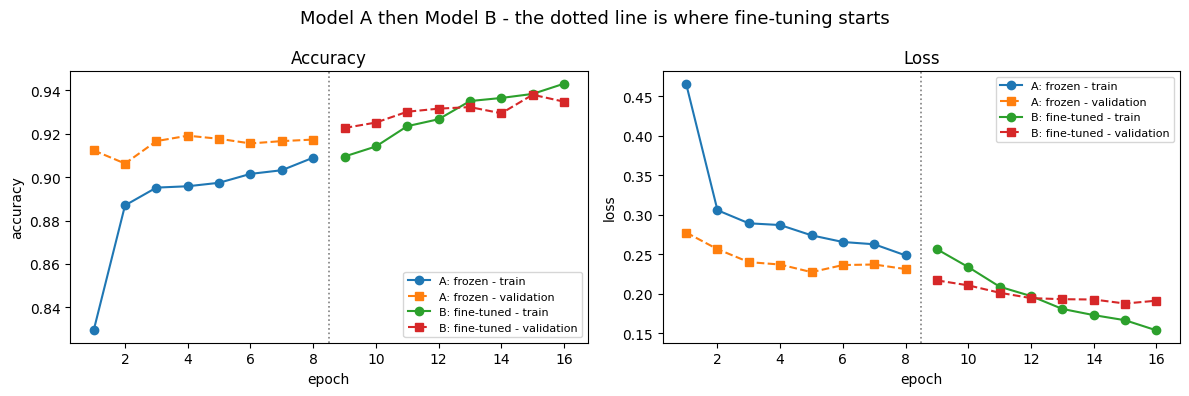

In [22]:
plot_history(
    [("A: frozen", history_head), ("B: fine-tuned", history_finetune)],
    "Model A then Model B - the dotted line is where fine-tuning starts",
)

## 7. Evaluation On The Test Data

The `seg_test` folder was never used for training and never used for any decision I made, so this is a clean held out score. I evaluate both models here, Model A (frozen backbone) and Model B (fine-tuned), so I can actually show that fine-tuning was worth the extra minutes instead of just assuming it.

In [23]:
y_true=np.concatenate([labels.numpy() for _, labels in test_ds])

probs_b=model.predict(test_ds, verbose=0)
y_pred_b=probs_b.argmax(axis=1)

model_a=keras.models.load_model(os.path.join(artifacts,"model_a_feature_extraction.keras"))
probs_a=model_a.predict(test_ds, verbose=0)
y_pred_a=probs_a.argmax(axis=1)

print(f"test images: {len(y_true)}")

test images: 3000


Accuracy on its own is not enough for a six class problem, so I also report:
- **balanced accuracy**, the average recall over the six classes, so a weak class cannot hide behind the strong ones
- **macro F1**, which treats every class as equally important
- **weighted F1**, which weights by class size

The classes here are close to balanced so these numbers should land near each other, and if they do not, that itself tells me one class is dragging the model down.

In [24]:
def score(y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

results=pd.DataFrame({
    "Model A (frozen)": score(y_pred_a),
    "Model B (fine-tuned)": score(y_pred_b),
}).T.round(4)

display(results)

,accuracy,balanced_accuracy,macro_f1,weighted_f1
Model A (frozen),0.9127,0.9149,0.9147,0.9123
Model B (fine-tuned),0.9300,0.9328,0.9319,0.9297


In [25]:
best_name=results["macro_f1"].idxmax()
is_b=best_name.startswith("Model B")

final_model=model if is_b else model_a
y_pred=y_pred_b if is_b else y_pred_a
probs=probs_b if is_b else probs_a

print(f"the model I keep: {best_name}")

the model I keep: Model B (fine-tuned)


### 7.1 Per Class Performance

In [26]:
report=classification_report(y_true, y_pred, target_names=class_names, digits=3, output_dict=True)

display(pd.DataFrame(report).T.round(3))

,precision,recall,f1-score,support
buildings,0.933,0.950,0.941,437.00
forest,0.990,0.996,0.993,474.00
glacier,0.909,0.834,0.870,553.00
mountain,0.851,0.901,0.875,525.00
sea,0.956,0.975,0.965,510.00
street,0.954,0.942,0.948,501.00
accuracy,0.930,0.930,0.930,0.93
macro avg,0.932,0.933,0.932,3000.00
weighted avg,0.930,0.930,0.930,3000.00


### 7.2 Confusion Matrix

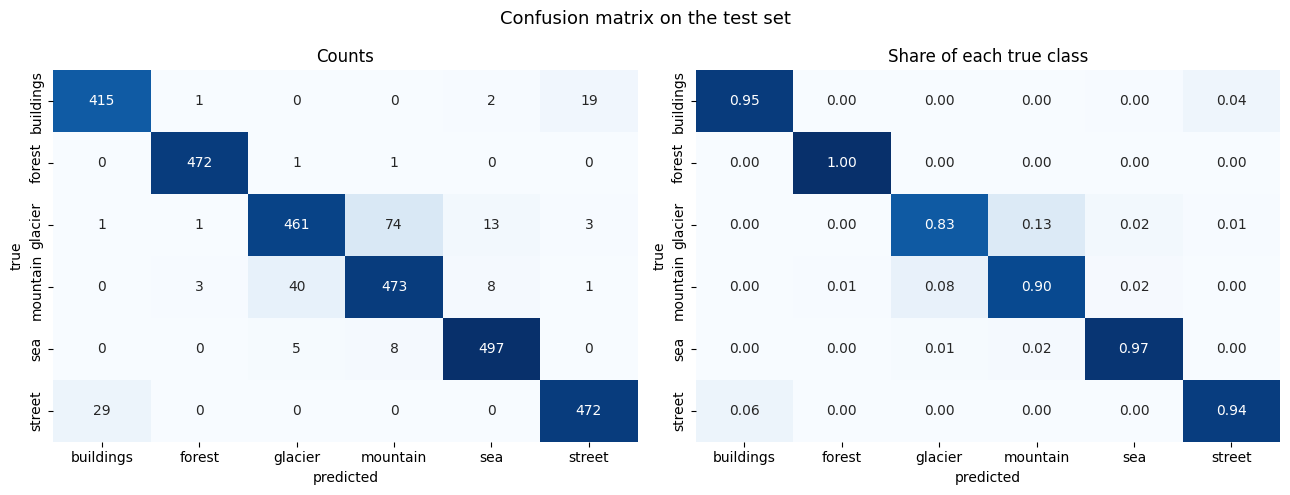

In [27]:
cm=confusion_matrix(y_true, y_pred)
cm_norm=cm/cm.sum(axis=1, keepdims=True)

fig, axes=plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set(title="Counts", xlabel="predicted", ylabel="true")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set(title="Share of each true class", xlabel="predicted", ylabel="true")

fig.suptitle("Confusion matrix on the test set", fontsize=13)
fig.tight_layout()
plt.show()

In [28]:
pairs=[]
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i!=j and cm[i, j]>0:
            pairs.append({
                "true": class_names[i],
                "predicted": class_names[j],
                "count": int(cm[i, j]),
                "share_of_true_class": round(cm[i, j]/cm[i].sum(), 3),
            })

confused=pd.DataFrame(pairs).sort_values("count", ascending=False).head(8).reset_index(drop=True)
display(confused)

,true,predicted,count,share_of_true_class
0,glacier,mountain,74,0.134
1,mountain,glacier,40,0.076
2,street,buildings,29,0.058
3,buildings,street,19,0.043
4,glacier,sea,13,0.024
5,mountain,sea,8,0.015
6,sea,mountain,8,0.016
7,sea,glacier,5,0.010


This is the part I actually cared about. The mistakes are not spread evenly at all, they sit on two pairs:

- **glacier and mountain**, in both directions and by a wide margin. 74 glacier photos were called mountain, which is 13.4% of every glacier in the test set, and 40 mountains came back as glacier. Nothing else is close. That is why glacier has the lowest recall of the six (0.834) and mountain the lowest precision (0.851), they are the same problem seen from two sides. It makes sense too, a glacier photo is usually a snowy slope under a sky and so is a mountain photo, the real difference is the ice texture and that is exactly the detail that survives worst at 150x150.
- **buildings and street**, 29 and 19 photos. Almost every street photo has buildings in it and almost every buildings photo was taken from a street, so the label depends on what the photographer meant to frame more than on what is in the image.

Sea and glacier trade a handful of photos for the same reason, both are a flat bright surface meeting the sky.

Forest is the cleanest class by far, F1 of 0.993 and only two photos lost, because it is the only one of the six with a texture nothing else shares. This is the same thing I guessed while looking at the sample images in the EDA, so it is nice to see the numbers agree.

### 7.3 The Mistakes It Was Most Sure About

210 wrong out of 3000


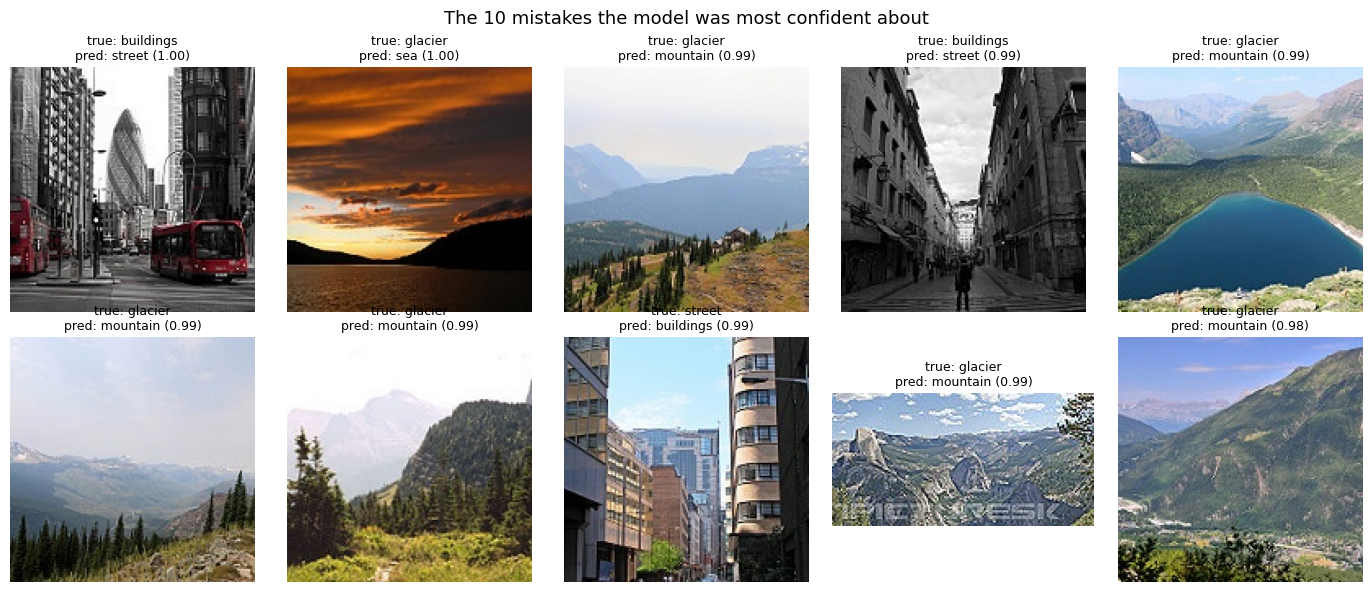

In [29]:
test_index=(all_images_df[all_images_df["split_name"]=="test"]
            .sort_values(["class_name","image_path"])
            .reset_index(drop=True))

# image_dataset_from_directory reads the folders in the same sorted order, this line makes sure of it
assert (test_index["class_name"].map(class_names.index).values==y_true).all()

test_index["predicted"]=[class_names[k] for k in y_pred]
test_index["confidence"]=probs.max(axis=1)

mistakes=test_index[test_index["class_name"]!=test_index["predicted"]].sort_values("confidence", ascending=False)
print(f"{len(mistakes)} wrong out of {len(test_index)}")

fig, axes=plt.subplots(2, 5, figsize=(14, 6))
for ax, (_, row_data) in zip(axes.ravel(), mistakes.head(10).iterrows()):
    ax.imshow(Image.open(row_data["image_path"]))
    ax.set_title(f"true: {row_data['class_name']}\npred: {row_data['predicted']} ({row_data['confidence']:.2f})", fontsize=9)
    ax.axis("off")

fig.suptitle("The 10 mistakes the model was most confident about", fontsize=13)
fig.tight_layout()
plt.show()

Worth looking at these closely, because they change how I read the error rate.

Six of the ten are labelled **glacier** and the model said **mountain** with 0.98 to 0.99 confidence, and in most of them I cannot see any ice at all, they are green valleys, treelines and a lake. If someone handed me those photos with no label I would have said mountain too. The same goes for the buildings photo it called street, which is a road with buses down the middle of it, and the glacier photo it called sea, which is a sunset over open water.

So a real part of what is being counted against the model here is label noise in the dataset rather than the model being wrong. That also explains why the glacier and mountain confusion is so stubborn, some of the training labels for those two classes disagree with each other, and no amount of training will fix a boundary the labels themselves do not respect. It is a good argument for the confidence based review flow in the next section, and for spot checking the glacier folder before spending more time on the model.

### 7.4 What This Means For The Review Team

The business ask was not only accuracy, it was that the review team should spend their time on the photos the model is genuinely unsure about. So the useful question is: if I only auto tag the photos where the model is confident, how much of the backlog does that clear, and how good is the tagging on that part?

In [30]:
confidence=probs.max(axis=1)
correct=(y_pred==y_true)

rows=[]
for threshold in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    auto=confidence>=threshold
    rows.append({
        "confidence_threshold": threshold,
        "auto_tagged_share": auto.mean(),
        "accuracy_on_auto_tagged": correct[auto].mean(),
        "photos_sent_to_review": int((~auto).sum()),
    })

display(pd.DataFrame(rows).round(3))

,confidence_threshold,auto_tagged_share,accuracy_on_auto_tagged,photos_sent_to_review
0,0.00,1.000,0.930,0
1,0.50,0.993,0.935,21
2,0.60,0.956,0.948,132
3,0.70,0.921,0.960,236
4,0.80,0.876,0.972,371
5,0.90,0.810,0.983,570
6,0.95,0.722,0.988,834


This table is the real answer to the business question, and it is a better result than the raw 93% suggests.

At a threshold of **0.70** the model tags **92.1%** of the photos by itself and is **96.0%** accurate on them, sending only 236 photos out of 3000 to a human. Push it to **0.90** and the auto tagged part is **98.3%** accurate while still clearing 81% of the uploads. So the review team goes from opening every single photo to opening one in five, and the ones they do open are the genuinely ambiguous ones.

Which threshold to actually ship is a product decision rather than a modelling one, it depends on how expensive a wrong tag is compared to a reviewer's time, so I leave the whole table instead of picking one number.

## 8. Saving What The Streamlit App Needs

The app should not know anything about training. I save one model file and one small json with the class order and the input size, and that is the whole contract between this notebook and `app.py`. The preprocessing lives inside the model itself (the rescaling layers are part of the graph), so the app only has to resize an uploaded photo and hand it over.

In [31]:
final_model.save(os.path.join(artifacts,"scene_model.keras"))

with open(os.path.join(artifacts,"class_names.json"),"w") as f:
    json.dump({"class_names": class_names, "img_size": list(img_size)}, f, indent=2)

print("artifacts folder:", os.listdir(artifacts))
print("tensorflow:", tf.__version__, "| keras:", keras.__version__)

artifacts folder: ['model_b_finetuned.keras', 'class_names.json', 'scene_model.keras', 'model_a_feature_extraction.keras']
tensorflow: 2.20.0 | keras: 3.13.2


In [32]:
# same path an uploaded photo will take inside the app, just to be sure it works outside a tf.data pipeline
sample=test_index.iloc[0]

img=Image.open(sample["image_path"]).convert("RGB").resize(img_size)
batch=np.expand_dims(np.array(img, dtype="float32"), axis=0)
p=final_model.predict(batch, verbose=0)[0]

print(f"true: {sample['class_name']}")
print(f"predicted: {class_names[int(p.argmax())]} with confidence {p.max():.2f}")

true: buildings
predicted: buildings with confidence 1.00


## 9. Write Up

**What I built.** A six class natural scene classifier on the Intel Image Classification dataset, built as transfer learning on MobileNetV2 in Keras and trained in two stages: the head only with the backbone frozen, then the last block of the backbone fine-tuned with a much smaller learning rate. It reaches **93.0% accuracy** and **0.932 macro F1** on the 3000 held out test photos. The final model is saved as a single file and served through a Streamlit app that takes an uploaded photo and returns the scene category with its confidence.

**What worked.** Transfer learning was clearly the right call, the frozen backbone was already at 91.2% validation accuracy after a single epoch, which a from scratch CNN would not come near in three minutes of training. Fine-tuning the last block was worth doing and cheap, it took the test accuracy from 91.3% to 93.0% and the macro F1 from 0.915 to 0.932 for less than four extra minutes. Early stopping with `restore_best_weights` mattered more than I expected, in both stages the last epoch was not the best one, stage A restored epoch 5 of 8 and stage B epoch 7 of 8. Light augmentation kept the gap between training and validation accuracy small the whole way, I never saw the two curves separate.

**What did not work as well.** The gains flatten out fast. By the end of the fine-tuning stage the validation loss was moving in the third decimal place, so more epochs were not going to be the answer. The errors that remain are not spread noise either, 114 of the 210 mistakes are just glacier and mountain arguing with each other, more than half of everything the model gets wrong, which means the overall accuracy number hides where the actual weakness is. Balanced accuracy and the per class report were what made that visible, on accuracy alone the model looks uniformly fine.

**Which classes get confused and why.** Glacier and mountain, in both directions, is the whole story: 74 glaciers called mountain and 40 mountains called glacier. At 150x150 both are a snowy slope under a sky, and the thing that really separates them, the ice texture and the shape of the ice front, is the first detail lost when a photo is downscaled. Buildings and street is second, and that one is arguably not the model's fault, most street photos contain buildings and most buildings photos were taken from a street, so the difference is the photographer's intent rather than the content. Sea and glacier swap a few for the same reason, a flat bright surface meeting a horizon. Forest is the easiest class because its texture is not shared with anything else in the six.

One thing I only saw by opening the images: a good part of the glacier and mountain error is the dataset disagreeing with itself. Six of the ten mistakes the model was most confident about are photos labelled glacier with no ice visible anywhere in them, and mountain is the answer I would have given as well. So the 93% is probably a slight understatement of how well the model actually reads a scene, and past a point I would be fitting the labelling noise rather than the problem.

**What I would try next with more time.**
- A stronger backbone such as EfficientNetV2 or ConvNeXt at a higher input resolution, since the pair that is costing me accuracy is exactly the pair that needs fine texture.
- Random crops on the images instead of resizing the whole frame, to stop throwing away the ice texture that separates glacier from mountain before the model ever sees it.
- Test time augmentation (average the prediction of the image and its mirror), a cheap way to pick up a bit on the borderline photos.
- Audit the glacier folder before touching the model again, since if a chunk of those labels are wrong then cleaning them is worth more than any architecture change.
- A dedicated glacier vs mountain classifier that only runs when the main model puts its top two probabilities on those two classes, since that one pair is where almost all the remaining error lives.
- On the product side, tune the confidence threshold from section 7.4 with the review team, since that single number decides how much of the backlog clears automatically.